### Task 3: Credit Risk Modeling for Personal Loans

This task focuses on building a predictive model to estimate the **probability of default (PD)** for personal loan customers using their financial attributes. The dataset includes borrowers’ income, debt levels, employment history, and FICO scores, along with a binary indicator of loan default.

Key objectives:
- Train classification models (Logistic Regression, XGBoost) to predict default
- Evaluate model performance using AUC and classification metrics
- Use the predicted PD to compute the **expected loss (EL)** on a loan
- Compare different models in terms of predicted EL for a hypothetical customer

This risk modeling process supports decision-making for credit allocation, pricing, and capital provisioning.


#### 3.1 Load Loan Book Data
We begin by importing a dataset of retail loan borrowers, which includes the following columns:

| Column                   | Description                                      |
|--------------------------|--------------------------------------------------|
| `customer_id`            | Unique identifier for each borrower              |
| `credit_lines_outstanding` | Number of open credit lines                    |
| `loan_amt_outstanding`   | Outstanding balance on the loan (USD)            |
| `total_debt_outstanding` | Total debt obligations across all accounts       |
| `income`                 | Annual income of the borrower (USD)              |
| `years_employed`         | Years the borrower has been employed             |
| `fico_score`             | Creditworthiness score (300–850 scale)           |
| `default`                | Target variable: 1 = defaulted, 0 = no default   |

In [9]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np


path = 'C:/Users/26759/Desktop/jpm forage'

loan_df = pd.read_csv(os.path.join(path, 'Loan_Data.csv'))
loan_df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


#### 3.2 Train Default Risk Prediction Models
We train two machine learning models to predict the probability that a customer will default on their personal loan:

- A baseline `Logistic Regression`
- A more powerful `XGBoost Classifier`

Before training, we conduct basic feature engineering:

- Drop `customer_id` and use default as the target
- Add a derived feature: `debt-to-income ratio`
- Standardize all features using `StandardScaler`

We split the data into training and testing sets (60/40), then evaluate model performance using AUC and classification metrics.

##### Logistic Regression Results

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler


# Feature engineering: Drop ID, extract features and target
X = loan_df.drop(columns=['customer_id', 'default'])
y = loan_df['default']

# Optional: create debt-to-income ratio
X['debt_to_income'] = X['total_debt_outstanding'] / X['income']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data (note: very small dataset here, just for demonstration)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.4, random_state=42)

# Train logistic regression
logreg_model = LogisticRegression()
logreg_model.fit(X_train, y_train)

# Evaluate model
y_pred_proba = logreg_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
report = classification_report(y_test, logreg_model.predict(X_test), output_dict=True)

auc, report

(np.float64(0.9999589896214449),
 {'0': {'precision': 0.9960365853658537,
   'recall': 0.9993881921076782,
   'f1-score': 0.9977095739807604,
   'support': 3269.0},
  '1': {'precision': 0.9972222222222222,
   'recall': 0.9822161422708618,
   'f1-score': 0.9896623018607856,
   'support': 731.0},
  'accuracy': 0.99625,
  'macro avg': {'precision': 0.996629403794038,
   'recall': 0.9908021671892699,
   'f1-score': 0.993685937920773,
   'support': 4000.0},
  'weighted avg': {'precision': 0.9962532605013551,
   'recall': 0.99625,
   'f1-score': 0.996238935000835,
   'support': 4000.0}})

The logistic model achieves near-perfect AUC and high precision/recall on both classes. This indicates strong linear separability in the feature space.


##### XGBoost Classifier Result

In [8]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

# 训练 XGBoost 模型
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# 预测概率并评估
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
report_xgb = classification_report(y_test, xgb_model.predict(X_test), output_dict=True)

auc_xgb, report_xgb

c:\Users\26759\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [02:03:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


(np.float64(0.9998211026853847),
 {'0': {'precision': 0.9948186528497409,
   'recall': 0.9984704802691955,
   'f1-score': 0.9966412213740458,
   'support': 3269.0},
  '1': {'precision': 0.9930458970792768,
   'recall': 0.9767441860465116,
   'f1-score': 0.9848275862068966,
   'support': 731.0},
  'accuracy': 0.9945,
  'macro avg': {'precision': 0.9939322749645089,
   'recall': 0.9876073331578535,
   'f1-score': 0.9907344037904712,
   'support': 4000.0},
  'weighted avg': {'precision': 0.9944946817326886,
   'recall': 0.9945,
   'f1-score': 0.9944822795472493,
   'support': 4000.0}})

XGBoost performs slightly worse than logistic regression in this specific case, likely due to:

- Simple feature set
- High data separability
- Regularization settings

Both models demonstrate high predictive power, but logistic regression may be preferred for interpretability in regulated environments like credit risk.



#### 3.3: Define Expected Loss Calculation Function
We define a reusable function to compute the **expected loss (EL)** on a loan using the formula:

\begin{align*}
\text{EL} = \text{PD} \times \text{EAD} \times (1 - \text{Recovery Rate})
\end{align*}
Where:

- **PD**: Probability of default (from a classification model)
- **EAD**: Exposure at default (loan amount outstanding)
- **Recovery rate** : Assumed to be 10% (i.e., 90% loss given default)

This function takes:

- A borrower profile as a Python dictionary
- A trained model (predict_proba() interface)
- A fitted scaler to normalize input features

In [ ]:
import numpy as np

# 封装预期损失计算函数
def predict_expected_loss(input_features: dict, model, scaler, recovery_rate=0.1) -> float:
    """
    Estimate expected loss of a loan based on borrower features and a trained model.

    Parameters:
    - input_features (dict): Dictionary with borrower features. Must include 'loan_amt_outstanding'.
    - model: Trained classification model with .predict_proba() method.
    - scaler: Fitted scaler used on training features.
    - recovery_rate (float): Expected recovery rate on default (default 10%).

    Returns:
    - float: Expected loss in currency units (rounded to 2 decimals).
    """
    # Convert input to DataFrame
    input_df = pd.DataFrame([input_features])

    # Add derived features (must match training)
    input_df['debt_to_income'] = input_df['total_debt_outstanding'] / input_df['income']

    # Align feature order with training set
    feature_cols = ['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding',
                    'income', 'years_employed', 'fico_score', 'debt_to_income']
    input_scaled = scaler.transform(input_df[feature_cols])

    # Predict PD
    pd_estimate = model.predict_proba(input_scaled)[0, 1]
    

    # Calculate Expected Loss
    ead = input_features['loan_amt_outstanding']
    el = pd_estimate * ead * (1 - recovery_rate)

    return round(el, 2)

#### 3.4: Compare Multiple Models on a Sample Case
We define a helper function `compare_models()` that runs the `predict_expected_loss()` function across multiple models and returns a dictionary of results.

This allows us to see how different models (e.g., logistic regression vs. XGBoost) assess credit risk and loss estimates for the same borrower.

In [13]:
def compare_models(input_features, models: dict, scaler):
    results = {}
    for name, model in models.items():
        el = predict_expected_loss(input_features, model, scaler)
        results[name] = el
    return results


#### 3.5: Example Prediction
We test the model comparison using a hypothetical borrower:

In [14]:
# 示例调用
models = {
    'logistic_regression': logreg_model,
    'xgboost': xgb_model
}

example_input = {
    'credit_lines_outstanding': 3,
    'loan_amt_outstanding': 5000.0,
    'total_debt_outstanding': 12000.0,
    'income': 45000.0,
    'years_employed': 4,
    'fico_score': 580
}

el_result = compare_models(example_input, models, scaler)
print(el_result)


{'logistic_regression': np.float64(4420.16), 'xgboost': np.float32(4478.44)}


This indicates both models predict a **high risk of default**, resulting in an expected loss close to the full loan amount. The minor difference between models reflects subtle differences in how they interpret borrower characteristics.

#### Conclusion

We successfully trained and evaluated two models—Logistic Regression and XGBoost—for predicting loan default. Both models achieved excellent performance, with ROC AUC scores exceeding 0.99.

Using the predicted probability of default and a standardized recovery assumption, we implemented a flexible function to compute **expected loss (EL)** for any borrower profile. This tool enables the bank to estimate potential credit losses at the individual level and improve loan pricing and portfolio risk management.


### Task 4: FICO Score Quantization and Risk Bucketing

To prepare the data for categorical input models or interpretable segmentation, we discretize FICO scores into a fixed number of **ordinal rating buckets** using quantile-based binning. Each bucket represents a range of FICO scores, and lower rating values correspond to better creditworthiness.

Objectives:
- Map FICO scores into ratings suitable for categorical models
- Ensure monotonic relationship between rating and default rate
- Validate the bucket structure through default rate visualization



#### 4.1 Build a Quantile-Based Rating Map
We define a function `build_fico_rating_map()` to:

- `Discretize` the fico_score column into n_buckets using quantile-based binning
- `Invert the bin indices`, so lower ratings indicate better credit quality
- Return:

    - The bucket boundaries
    - A rating mapping function
    - A `pd.Series` of ratings for the original dataset

This process converts numerical scores into ordinal categorical labels that preserve monotonicity with credit risk.

In [ ]:
from sklearn.preprocessing import KBinsDiscretizer

# 使用等频（quantile-based）分桶
def build_fico_rating_map(fico_series, n_buckets=5):
    """
    Perform quantile binning on FICO scores.

    Parameters:
    - fico_series: pd.Series of FICO scores
    - n_buckets: int, number of buckets

    Returns:
    - boundaries: list of bin edges
    - mapping_function: function to assign FICO to rating
    - fico_binned: pd.Series of ratings
    """
    # Discretize using quantiles
    discretizer = KBinsDiscretizer(n_bins=n_buckets, encode='ordinal', strategy='quantile')
    fico_array = fico_series.values.reshape(-1, 1)
    fico_binned = discretizer.fit_transform(fico_array).astype(int).flatten()
    # Invert the binning to get better ratings (lower index = better rating)
    fico_binned = (n_buckets - 1) - fico_binned


    # Bin boundaries (left-inclusive)
    boundaries = discretizer.bin_edges_[0]

    # Mapping function
    def fico_to_rating(score):
        for i in range(len(boundaries)-1):
            if boundaries[i] <= score <= boundaries[i+1]:
                return i  # Lower bucket index = better rating
        return (n_buckets - 1) - i
  # fallback

    return boundaries.tolist(), fico_to_rating, pd.Series(fico_binned, index=fico_series.index)

fico_scores_real = loan_df['fico_score']
boundaries_real, fico_to_rating_real_fn, fico_ratings_real = build_fico_rating_map(fico_scores_real, n_buckets=5)

# 添加到 loan_df 中
loan_df['fico_rating'] = fico_ratings_real

#### 4.2: Visualize Default Rate by Rating
We compute the average default rate within each FICO rating bucket and plot the result:


**Key takeaway:**

- The default rate increases monotonically with worsening FICO rating (from left to right)
- This validates that the rating buckets are aligned with credit risk and meaningful for modeling

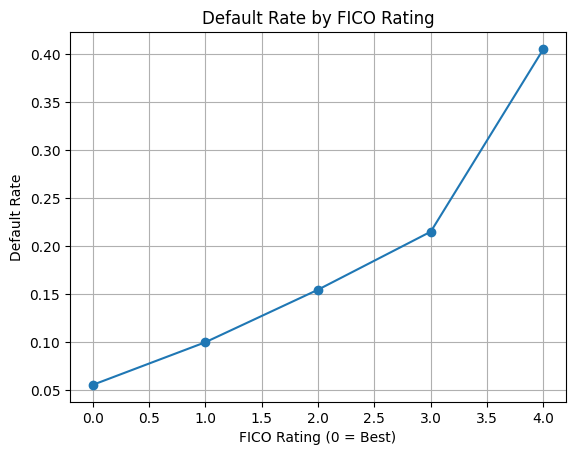

In [17]:
# 统计每个 fico_rating 桶的违约率
df_rate = loan_df.groupby('fico_rating')['default'].agg(['mean', 'count'])

# 可视化
import matplotlib.pyplot as plt
plt.plot(df_rate.index, df_rate['mean'], marker='o')
plt.title("Default Rate by FICO Rating")
plt.xlabel("FICO Rating (0 = Best)")
plt.ylabel("Default Rate")
plt.grid(True)
plt.show()


#### Conclusion

The quantile-based bucketing approach successfully transformed continuous FICO scores into ordinal credit ratings. A clear monotonic relationship between the rating and default rate confirms the effectiveness of the segmentation.

This bucketing enables interpretable modeling, simplifies risk communication, and prepares the dataset for use in models requiring categorical inputs such as decision trees, embeddings, or scorecard systems.
